# Simulating Xenium-like data (cell-resolution)

This notebook reproduces the **exact configuration** used to validate
`albis`'s Xenium-like, single-cell-resolution output against real Xenium
data in the manuscript's Figure 2 (the `cell_vs_non_diseased_lung` /
`cell_vs_lung_cancer` count-distribution comparisons).

It uses the same low-level `simulate_3d_molecule_sphere_multires` API as
`lower_level_api_tutorial.ipynb` -- the higher-level `generate_data()`
wrapper does not expose `theta`/`theta_jitter`/`base_gene_lognormal`/
`batch_sigma`, all of which this configuration tunes away from their
defaults.

## Setup

Install Albis, including plotting support, in your Python environment:

```bash
pip install albis
```

Download this notebook and open it in Jupyter using the same environment.
If Jupyter is not already installed:

```bash
pip install notebook
jupyter notebook
```

If you are already in a notebook, run `%pip install albis` in a cell to
install into the active kernel, then restart the kernel if needed.


In [1]:
from pathlib import Path

import albis as ab
import numpy as np

print("Albis version:", ab.__version__)


Albis version: 0.1.2


## The exact Figure 2 "cell" configuration

Grouped the same way as `lower_level_api_tutorial.ipynb`'s config dict.
Comments mark which values are manuscript-specific tuning vs. left at the
simulator's own defaults. The two knobs that make this "Xenium-like"
specifically are `xenium_capture_window_um` (the real Xenium slide's 12x24mm
window, cropping cell-level output) and the single-cell `output_modalities`
selection itself -- Visium/VisiumHD aggregate multiple cells per
observation, Xenium (here) does not.

In [2]:
sphere_r_um = 2050.0          # TUNED: same tissue disc as the bin and spot configurations

config = {
    # ==== 3D tissue geometry and cell placement ====
    "sphere_R_um": sphere_r_um,
    "center": (0.0, 0.0, 0.0),                 # default
    "n_cells": 24_207,                         # TUNED: Figure 2 cell count for the 2050um disc
    "allow_cell_overlap": False,               # default
    "cell_radius_kwargs": dict(                # r_mean/r_sigma tuned; r_min/r_max scaled proportionally
        radius_dist="lognormal", r_mean=7.5, r_sigma=0.28, r_min=4.0, r_max=14.0,
    ),

    # ==== Spatial domains with irregular boundaries (manuscript-wide, all 4 pairings) ====
    "n_domains": 6,
    "core_frac": 0.55,
    "core_bump_amp": 0.25,
    "wedge_angle_amp_deg": 25.0,
    "noise_terms": 16,
    "noise_freq_range": (3.0, 6.0),
    "boundary_fuzz_width_deg": 6.0,
    "boundary_fuzz_flip_prob": 0.15,
    "core_fuzz_width_um": 0.05 * sphere_r_um,  # manuscript ratio: scales with sphere_R_um
    "core_fuzz_flip_prob": 0.25,

    # ==== Cell type composition by domain ====
    "n_cell_types": 8,
    "domain_type_mix": None,   # filled in below (manuscript_domain_type_mix)

    # ==== Gene programs and per-cell gene expression ====
    "marker_genes_per_type": 80,               # default
    "noise_gene_frac": 0.10,                   # default
    "shared_marker_frac": 0.25,                # default
    "base_gene_lognormal": (-2.5, 0.7),        # TUNED: lowers avg. per-cell total counts vs. default (0.7, 0.7)
    "marker_foldchange": 3.5,                  # default
    "shared_marker_foldchange": 2.5,           # default
    "noise_scale": 1.3,                        # TUNED: manuscript "noisy" baseline (default 0.9)
    "cell_size_lognormal": (0.0, 0.35),        # default
    "domain_size_factors": None,               # default (no per-domain expression shift)
    "theta": 0.40,                             # TUNED: NB dispersion (real Xenium fits theta_hat ~0.15-0.16)
    "theta_jitter": 0.15,                      # TUNED: per-gene spread of theta around 0.40

    # ==== Transcript-level molecule simulation ====
    "inside_prob": 0.95,                       # default
    "assign_k": 8,                             # default

    # ==== Platform-specific capture windows ====
    "xenium_capture_window_um": (12000.0, 24000.0),  # real Xenium slide window (12x24mm) -- crops cell output
    "capture_window_um": (6500.0, 6500.0),           # unused for cell output, kept for completeness
    "capture_window_center_um": (0.0, 0.0),          # default
    "bin_size_um": 8.0,                              # unused for cell output
    "spot_spacing_um": 100.0,                        # unused for cell output
    "spot_radius_um": 27.5,                          # unused for cell output

    # ==== Slicing, batch effects, and unaligned coordinates ====
    "n_slices": 10,
    "slice_axes": ("Z",),
    "batch_sigma": 1.5,                        # TUNED: per-slice technical batch effect
    "max_deg": 270.0,
    "max_shift": 0.5 * sphere_r_um,            # manuscript ratio: scales with sphere_R_um
    "base_seed_unaligned": 12345,              # default
    "sync_unaligned_seed": True,               # same per-slice misalignment across cell/bin/spot

    # ==== Simulation outputs ====
    "output_modalities": ("cell",),            # single-cell resolution -- the defining choice for "Xenium-like"
    "sparse_X": True,                          # default
    "seed": 2025,                              # default
}


In [3]:
# Manuscript-baseline domain_type_mix (6 domains x 8 cell types). Every domain
# gets a distinct, non-uniform composition -- this is what Figure 2/3's
# domain_true and cell_type_true ground truth is built on. (An alternative
# "strong" mix with much sharper per-domain enrichment exists for dedicated
# domain-recovery test runs, but every Figure 2 count-distribution config uses
# this manuscript-baseline matrix.)
manuscript_domain_type_mix = np.array([
    [0.18, 0.18, 0.13, 0.12, 0.11, 0.10, 0.09, 0.09],
    [0.11, 0.12, 0.18, 0.18, 0.13, 0.10, 0.09, 0.09],
    [0.10, 0.11, 0.12, 0.13, 0.18, 0.18, 0.09, 0.09],
    [0.10, 0.10, 0.11, 0.12, 0.13, 0.13, 0.16, 0.15],
    [0.14, 0.13, 0.12, 0.11, 0.12, 0.13, 0.13, 0.12],
    [0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125],
])
config["domain_type_mix"] = manuscript_domain_type_mix


> **Runtime.** This configuration simulates 24,207 cells, so it runs much
> faster than the bin and spot tutorials (600,000 cells each). Every
> parameter above is the exact Figure 2 value.


## Generate

`simulate_3d_molecule_sphere_multires(**config)` builds the 3D tissue once,
then slices/captures/applies the batch effect for the requested modality.

In [4]:
sim = ab.simulate_3d_molecule_sphere_multires(**config)

print("top-level keys:", list(sim.keys()))
adata = sim["adata_cell_sectioned"]["Z"]
adata


top-level keys: ['adata_cell_true', 'adata_cell_obs', 'adata_cell_sectioned', 'bin_adatas', 'spot_adatas', 'meta']


AnnData object with n_obs × n_vars = 24207 × 556
    obs: 'domain_true', 'cell_type_true', 'cell_radius', 'cell_sigma_for_95pct', 'slice_id_X', 'slice_id_Y', 'slice_id_Z', 'slice_axis', 'slice_id'
    var: 'gene_class', 'is_noise', 'is_shared_marker'
    uns: 'sim_params', 'batch_effect_factors', 'rigid_perturb_inplane'
    obsm: 'spatial', 'spatial_3d', 'spatial_unaligned', 'spatial_3d_unaligned'
    layers: 'counts_pre_batch'

## Inspect the output

In [5]:
print(adata)
print()
print("n_obs (observations):", adata.n_obs)
print("n_vars (genes):", adata.n_vars)
print("obs columns:", list(adata.obs.columns))
print("var columns:", list(adata.var.columns))


AnnData object with n_obs × n_vars = 24207 × 556
    obs: 'domain_true', 'cell_type_true', 'cell_radius', 'cell_sigma_for_95pct', 'slice_id_X', 'slice_id_Y', 'slice_id_Z', 'slice_axis', 'slice_id'
    var: 'gene_class', 'is_noise', 'is_shared_marker'
    uns: 'sim_params', 'batch_effect_factors', 'rigid_perturb_inplane'
    obsm: 'spatial', 'spatial_3d', 'spatial_unaligned', 'spatial_3d_unaligned'
    layers: 'counts_pre_batch'

n_obs (observations): 24207
n_vars (genes): 556
obs columns: ['domain_true', 'cell_type_true', 'cell_radius', 'cell_sigma_for_95pct', 'slice_id_X', 'slice_id_Y', 'slice_id_Z', 'slice_axis', 'slice_id']
var columns: ['gene_class', 'is_noise', 'is_shared_marker']


In [6]:
summary = ab.describe(adata)
summary


{'n_obs': 24207,
 'n_vars': 556,
 'total_counts': 5932163,
 'nonzero_counts': 877660,
 'platform': None,
 'slice_axis': None,
 'n_slices': 10,
 'slice_ids': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 'obs_columns': ['domain_true',
  'cell_type_true',
  'cell_radius',
  'cell_sigma_for_95pct',
  'slice_id_X',
  'slice_id_Y',
  'slice_id_Z',
  'slice_axis',
  'slice_id'],
 'var_columns': ['gene_class', 'is_noise', 'is_shared_marker'],
 'layers': ['counts_pre_batch'],
 'obsm_keys': ['spatial',
  'spatial_3d',
  'spatial_unaligned',
  'spatial_3d_unaligned'],
 'uns_keys': ['sim_params', 'batch_effect_factors', 'rigid_perturb_inplane'],
 'truth_annotations': ["layers['counts_pre_batch']",
  "obs['cell_type_true']",
  "obs['domain_true']",
  "obs['cell_radius']",
  "obs['cell_sigma_for_95pct']"]}

### Empirical count dispersion

`generate_simulation_noisy.py` (the manuscript script this notebook mirrors)
fits an empirical per-gene NB dispersion from the pre-batch counts as a sanity
check against real platform data via
`sim_paper/code/count_distribution/count_distribution.py --compare-input`.
Same check here:

In [7]:
def fit_empirical_theta(X):
    """Same method count_distribution.py uses to fit an empirical NB dispersion
    from a count matrix, for comparing against real platform data."""
    if hasattr(X, "multiply"):
        mean = np.asarray(X.mean(axis=0)).ravel()
        mean_sq = np.asarray(X.multiply(X).mean(axis=0)).ravel()
    else:
        mean = X.mean(axis=0)
        mean_sq = (X ** 2).mean(axis=0)
    var = mean_sq - mean ** 2
    overdispersed = var > mean
    theta_hat = mean[overdispersed] ** 2 / (var[overdispersed] - mean[overdispersed])
    theta_hat = theta_hat[np.isfinite(theta_hat) & (theta_hat > 0)]
    return float(np.median(theta_hat)) if theta_hat.size else float("nan")

raw_counts = adata.layers["counts_pre_batch"] if "counts_pre_batch" in adata.layers else adata.X
empirical_theta = fit_empirical_theta(raw_counts)
print(f"empirical theta_hat = {empirical_theta:.3f}")


empirical theta_hat = 0.228


## Plot

`ab.plot()` returns a Matplotlib figure. `coordinates="aligned"` shows the
canonical tissue coordinates (what `domain_true`/`cell_type_true` were
assigned against); `coordinates="unaligned"` shows the per-slice rigid
misalignment `max_deg`/`max_shift` introduce -- the same synthetic
registration-error ground truth used elsewhere in the manuscript.

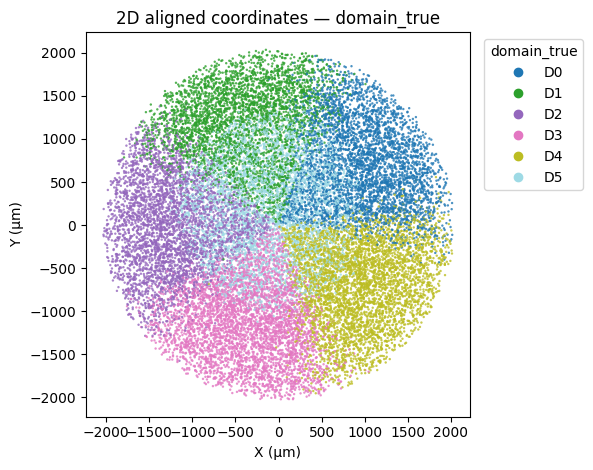

In [8]:
fig = ab.plot(adata, view="2d", coordinates="aligned", color="domain_true", point_size=3)


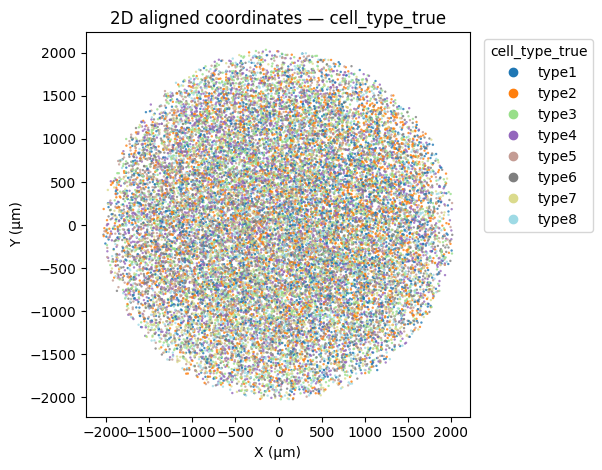

In [9]:
fig = ab.plot(adata, view="2d", coordinates="aligned", color="cell_type_true", point_size=3)


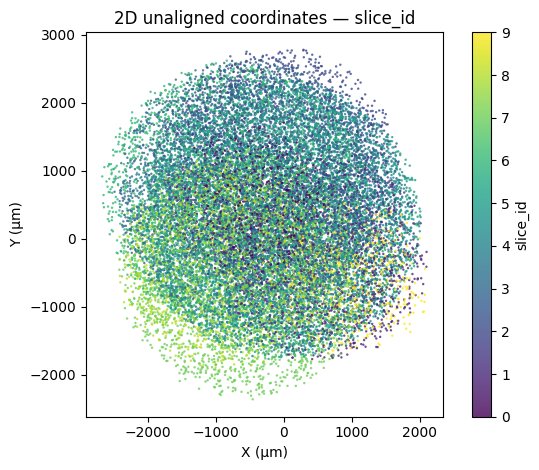

In [10]:
fig = ab.plot(adata, view="2d", coordinates="unaligned", color="slice_id", point_size=3)


## Save

Same `ab.save(...)` helper as the other two tutorials -- writes an `AnnData`
to `.h5ad` and returns the path.

In [11]:
output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

output_path = ab.save(adata, output_dir / "xenium_cell_z.h5ad")
output_path


PosixPath('outputs/xenium_cell_z.h5ad')